In [1]:
import os
import json
import zipfile
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Set dataset path
DATASET_PATH = Path("/home/tomtom/Desktop/FineBio")

# Configure plotting
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        pass
sns.set_palette("husl")
%matplotlib inline


## 1. Dataset Structure Overview


In [2]:
# List all directories in the dataset
directories = [d for d in DATASET_PATH.iterdir() if d.is_dir() and not d.name.startswith('.')]
directories.sort()

print("FineBio Dataset Structure:")
print("=" * 80)
for dir_path in directories:
    size = sum(f.stat().st_size for f in dir_path.rglob('*') if f.is_file())
    size_gb = size / (1024**3)
    print(f"{dir_path.name:50s} {size_gb:8.2f} GB")
    
print("\n" + "=" * 80)
total_size = sum(f.stat().st_size for f in DATASET_PATH.rglob('*') if f.is_file())
print(f"{'Total Dataset Size':50s} {total_size/(1024**3):8.2f} GB")


FineBio Dataset Structure:
01 annotations                                         0.01 GB
02 ckpts                                               2.23 GB
03 finebio_videos_fpv_all_w640                         6.23 GB
04 finebio_videos_fpv_test                            19.05 GB
05 finebio_videos_tpv_train                           59.18 GB
06 finebio_videos_tpv_valid                           13.30 GB
07 finebio_mistake_trials                              1.65 GB
08 finebio_videos_tpv_test                            11.97 GB
09 finebio_videos_fpv_train                           28.50 GB
10 finebio_videos_tpv_all_w640                         8.24 GB
11 finebio_videos_fpv_valid                            6.12 GB
12 finebio_object_detection_images                     0.24 GB
13 features                                           13.48 GB
14 misc                                                0.06 GB
All Zip                                              156.83 GB

Total Dataset Size         

## 2. Directory-by-Directory Analysis


In [3]:
def analyze_directory(dir_path, file_extensions=None):
    """Analyze a directory and return statistics"""
    stats = {
        'total_files': 0,
        'file_types': defaultdict(int),
        'total_size': 0,
        'files': []
    }
    
    for file_path in dir_path.rglob('*'):
        if file_path.is_file():
            stats['total_files'] += 1
            stats['total_size'] += file_path.stat().st_size
            
            ext = file_path.suffix.lower()
            stats['file_types'][ext] += 1
            
            if file_extensions is None or ext in file_extensions:
                stats['files'].append(file_path)
    
    return stats

# Analyze each main directory
directory_stats = {}
for dir_path in directories:
    if dir_path.name != "All Zip":  # Skip the zip directory
        stats = analyze_directory(dir_path)
        directory_stats[dir_path.name] = stats

# Display statistics
print("Directory Statistics:")
print("=" * 100)
for dir_name, stats in directory_stats.items():
    print(f"\n{dir_name}:")
    print(f"  Total files: {stats['total_files']}")
    print(f"  Total size: {stats['total_size']/(1024**3):.2f} GB")
    print(f"  File types: {dict(stats['file_types'])}")


Directory Statistics:

01 annotations:
  Total files: 2
  Total size: 0.01 GB
  File types: {'.zip': 2}

02 ckpts:
  Total files: 7
  Total size: 2.23 GB
  File types: {'.pth': 4, '.tar': 1, '.model': 2}

03 finebio_videos_fpv_all_w640:
  Total files: 226
  Total size: 6.23 GB
  File types: {'.mp4': 226}

04 finebio_videos_fpv_test:
  Total files: 185
  Total size: 19.05 GB
  File types: {'.mp4': 185}

05 finebio_videos_tpv_train:
  Total files: 785
  Total size: 59.18 GB
  File types: {'.mp4': 785}

06 finebio_videos_tpv_valid:
  Total files: 150
  Total size: 13.30 GB
  File types: {'.mp4': 150}

07 finebio_mistake_trials:
  Total files: 24
  Total size: 1.65 GB
  File types: {'.mp4': 18, '.txt': 3, '.npz': 3}

08 finebio_videos_tpv_test:
  Total files: 175
  Total size: 11.97 GB
  File types: {'.mp4': 175}

09 finebio_videos_fpv_train:
  Total files: 161
  Total size: 28.50 GB
  File types: {'.mp4': 161}

10 finebio_videos_tpv_all_w640:
  Total files: 1110
  Total size: 8.24 GB
  Fi

## 3. Annotations Analysis


In [4]:
# Extract and analyze action annotations
annotations_dir = DATASET_PATH / "01 annotations"
action_annotations_zip = annotations_dir / "finebio_action_annotations.zip"
coco_annotations_zip = annotations_dir / "finebio_coco_annotations.zip"

print("Annotation Files:")
print("=" * 80)

# Check action annotations
if action_annotations_zip.exists():
    with zipfile.ZipFile(action_annotations_zip, 'r') as z:
        action_files = [f for f in z.namelist() if f.endswith('.txt')]
        print(f"\nAction Annotations: {len(action_files)} files")
        
        # Read a sample annotation file
        if action_files:
            sample_file = action_files[0]
            with z.open(sample_file) as f:
                content = f.read().decode('utf-8')
                lines = content.split('\n')
                print(f"\nSample annotation file: {sample_file}")
                print(f"First 10 lines:")
                for i, line in enumerate(lines[:10], 1):
                    print(f"  {i}: {line}")
                
                # Parse CSV structure
                if len(lines) > 1:
                    header = lines[0]
                    print(f"\nAnnotation columns: {header}")
                    
                    # Count non-empty rows
                    data_rows = [l for l in lines[1:] if l.strip()]
                    print(f"Total annotation rows in sample: {len(data_rows)}")

# Check COCO annotations
if coco_annotations_zip.exists():
    with zipfile.ZipFile(coco_annotations_zip, 'r') as z:
        coco_files = [f for f in z.namelist() if f.endswith('.json')]
        print(f"\nCOCO Annotations: {len(coco_files)} files")
        
        # List all COCO annotation files
        print("\nCOCO annotation files:")
        for coco_file in sorted(coco_files):
            info = z.getinfo(coco_file)
            size_mb = info.file_size / (1024**2)
            print(f"  {coco_file:50s} {size_mb:8.2f} MB")
        
        # Read a sample COCO file
        if coco_files:
            sample_coco = "finebio_coco_annotations/v1_train_fpv.json"
            if sample_coco in coco_files:
                with z.open(sample_coco) as f:
                    coco_data = json.load(f)
                    print(f"\nSample COCO file: {sample_coco}")
                    print(f"  Info: {coco_data.get('info', {})}")
                    print(f"  Number of categories: {len(coco_data.get('categories', []))}")
                    print(f"  Number of images: {len(coco_data.get('images', []))}")
                    print(f"  Number of annotations: {len(coco_data.get('annotations', []))}")
                    
                    # Show categories
                    categories = coco_data.get('categories', [])
                    print(f"\n  Categories (first 10):")
                    for cat in categories[:10]:
                        print(f"    ID {cat['id']}: {cat['name']} ({cat.get('supercategory', 'N/A')})")
                    
                    # Show sample image info
                    images = coco_data.get('images', [])
                    if images:
                        print(f"\n  Sample image info:")
                        sample_img = images[0]
                        for key, value in sample_img.items():
                            print(f"    {key}: {value}")
                    
                    # Show sample annotation
                    annotations = coco_data.get('annotations', [])
                    if annotations:
                        print(f"\n  Sample annotation:")
                        sample_ann = annotations[0]
                        for key, value in sample_ann.items():
                            if key != 'segmentation':  # Skip long segmentation data
                                print(f"    {key}: {value}")


Annotation Files:

Action Annotations: 226 files

Sample annotation file: finebio_action_annotations/P03_02_01.txt
First 10 lines:
  1: start_sec,end_sec,task,hand_side,verb,manipulated_object,affected_object
  2: 1.0,24.92,remove_culture_medium,,,,
  3: 24.96,39.85,add_pbs,,,,
  4: 39.87,44.9,shake_plate,,,,
  5: 44.97,56.07,aspirate_pbs,,,,
  6: 56.16,69.16,add_pbs,,,,
  7: 69.2,73.99,shake_plate,,,,
  8: 74.06,83.8,aspirate_pbs,,,,
  9: 83.85,101.24,add_cell_lystate,,,,
  10: 101.25,107.24,shake_plate,,,,

Annotation columns: start_sec,end_sec,task,hand_side,verb,manipulated_object,affected_object
Total annotation rows in sample: 169

COCO Annotations: 15 files

COCO annotation files:
  finebio_coco_annotations/v1_all.json                  18.34 MB
  finebio_coco_annotations/v1_all_fpv.json              12.61 MB
  finebio_coco_annotations/v1_all_tpv.json               5.69 MB
  finebio_coco_annotations/v1_test_fpv.json              2.10 MB
  finebio_coco_annotations/v1_test_joint.js

In [5]:
# Analyze all action annotation files
action_annotations_data = []

if action_annotations_zip.exists():
    with zipfile.ZipFile(action_annotations_zip, 'r') as z:
        action_files = [f for f in z.namelist() if f.endswith('.txt')]
        
        for action_file in tqdm(action_files, desc="Processing action annotations"):
            with z.open(action_file) as f:
                content = f.read().decode('utf-8')
                lines = content.split('\n')
                
                if len(lines) > 1:
                    # Parse CSV
                    header = lines[0].split(',')
                    video_name = Path(action_file).stem
                    
                    task_annotations = []
                    action_annotations = []
                    
                    for line in lines[1:]:
                        if line.strip():
                            parts = line.split(',')
                            if len(parts) >= len(header):
                                row_data = dict(zip(header, parts))
                                
                                # Separate task-level and action-level annotations
                                if row_data.get('task'):
                                    task_annotations.append(row_data)
                                elif row_data.get('verb'):
                                    action_annotations.append(row_data)
                    
                    action_annotations_data.append({
                        'video': video_name,
                        'num_tasks': len(task_annotations),
                        'num_actions': len(action_annotations),
                        'tasks': task_annotations,
                        'actions': action_annotations
                    })

# Create DataFrame for analysis
if action_annotations_data:
    df_annotations = pd.DataFrame([
        {
            'video': item['video'],
            'num_tasks': item['num_tasks'],
            'num_actions': item['num_actions']
        }
        for item in action_annotations_data
    ])
    
    print("Action Annotations Statistics:")
    print("=" * 80)
    print(f"Total videos with annotations: {len(df_annotations)}")
    print(f"\nTask annotations:")
    print(f"  Total tasks: {df_annotations['num_tasks'].sum()}")
    print(f"  Average tasks per video: {df_annotations['num_tasks'].mean():.2f}")
    print(f"  Min tasks: {df_annotations['num_tasks'].min()}")
    print(f"  Max tasks: {df_annotations['num_tasks'].max()}")
    
    print(f"\nAction annotations:")
    print(f"  Total actions: {df_annotations['num_actions'].sum()}")
    print(f"  Average actions per video: {df_annotations['num_actions'].mean():.2f}")
    print(f"  Min actions: {df_annotations['num_actions'].min()}")
    print(f"  Max actions: {df_annotations['num_actions'].max()}")
    
    # Analyze unique tasks and actions
    all_tasks = []
    all_actions = []
    all_verbs = []
    all_objects = []
    all_hand_sides = []
    
    for item in action_annotations_data:
        for task in item['tasks']:
            if task.get('task'):
                all_tasks.append(task['task'])
        for action in item['actions']:
            if action.get('verb'):
                all_verbs.append(action['verb'])
            if action.get('manipulated_object'):
                all_objects.append(action['manipulated_object'])
            if action.get('hand_side'):
                all_hand_sides.append(action['hand_side'])
    
    print(f"\nUnique tasks: {len(set(all_tasks))}")
    print(f"Unique verbs: {len(set(all_verbs))}")
    print(f"Unique objects: {len(set([o for o in all_objects if o]))}")
    
    print(f"\nTop 10 tasks:")
    from collections import Counter
    task_counts = Counter(all_tasks)
    for task, count in task_counts.most_common(10):
        print(f"  {task:40s} {count:5d}")
    
    print(f"\nTop 10 verbs:")
    verb_counts = Counter(all_verbs)
    for verb, count in verb_counts.most_common(10):
        print(f"  {verb:40s} {count:5d}")
    
    print(f"\nHand side distribution:")
    hand_counts = Counter(all_hand_sides)
    for hand, count in hand_counts.most_common():
        print(f"  {hand:40s} {count:5d}")
else:
    print("Action annotations zip file not found or empty")


Processing action annotations: 100%|██████████| 226/226 [00:00<00:00, 555.85it/s]


Action Annotations Statistics:
Total videos with annotations: 226

Task annotations:
  Total tasks: 3541
  Average tasks per video: 15.67
  Min tasks: 9
  Max tasks: 31

Action annotations:
  Total actions: 50659
  Average actions per video: 224.15
  Min actions: 117
  Max actions: 559

Unique tasks: 32
Unique verbs: 10
Unique objects: 27

Top 10 tasks:
  spindown                                   529
  pipetting                                  277
  aspirate_supernatant                       270
  vortex                                     268
  place_in_magnetic_rack                     230
  shake_plate                                227
  add_wash_buffer                            146
  add_pbs                                    136
  aspirate_pbs                               136
  dispense_solution                          132

Top 10 verbs:
  put                                       8881
  take                                      8665
  press                                  

In [6]:
# Analyze video directories
video_directories = {
    'FPV All w640': DATASET_PATH / "03 finebio_videos_fpv_all_w640",
    'FPV Test': DATASET_PATH / "04 finebio_videos_fpv_test",
    'FPV Train': DATASET_PATH / "09 finebio_videos_fpv_train",
    'FPV Valid': DATASET_PATH / "11 finebio_videos_fpv_valid",
    'TPV Train': DATASET_PATH / "05 finebio_videos_tpv_train" / "finebio_videos",
    'TPV Valid': DATASET_PATH / "06 finebio_videos_tpv_valid" / "finebio_videos",
    'TPV Test': DATASET_PATH / "08 finebio_videos_tpv_test" / "finebio_videos",
    'TPV All w640': DATASET_PATH / "10 finebio_videos_tpv_all_w640" / "finebio_videos_w640",
    'Mistake Trials': DATASET_PATH / "07 finebio_mistake_trials" / "finebio_mistake_trials"
}

video_stats = {}

for name, video_dir in video_directories.items():
    if video_dir.exists():
        video_files = list(video_dir.glob("*.mp4"))
        video_stats[name] = {
            'count': len(video_files),
            'total_size': sum(f.stat().st_size for f in video_files),
            'files': video_files
        }
        
        # Analyze video naming pattern
        if video_files:
            sample_name = video_files[0].stem
            print(f"{name}:")
            print(f"  Number of videos: {video_stats[name]['count']}")
            print(f"  Total size: {video_stats[name]['total_size']/(1024**3):.2f} GB")
            print(f"  Sample filename: {video_files[0].name}")
            
            # Parse naming pattern (e.g., P01_01_01 or P01_01_01_T1)
            parts = sample_name.split('_')
            if len(parts) >= 3:
                print(f"  Naming pattern: P{parts[0][1:]}_XX_XX (Participant_Task_Trial)")
            if 'T' in sample_name:
                print(f"  Contains trial segments (T1, T2, T3, T4, T5)")
            print()

# Summary
print("Video Statistics Summary:")
print("=" * 80)
total_fpv = sum(s['count'] for k, s in video_stats.items() if 'FPV' in k)
total_tpv = sum(s['count'] for k, s in video_stats.items() if 'TPV' in k)
print(f"Total FPV videos: {total_fpv}")
print(f"Total TPV videos: {total_tpv}")
print(f"Total videos: {total_fpv + total_tpv}")


FPV All w640:
  Number of videos: 226
  Total size: 6.23 GB
  Sample filename: P10_01_01.mp4
  Naming pattern: P10_XX_XX (Participant_Task_Trial)

FPV Test:
  Number of videos: 185
  Total size: 19.05 GB
  Sample filename: P09_02_01_T3.mp4
  Naming pattern: P09_XX_XX (Participant_Task_Trial)
  Contains trial segments (T1, T2, T3, T4, T5)

TPV Train:
  Number of videos: 785
  Total size: 59.18 GB
  Sample filename: P04_04_02_T1.mp4
  Naming pattern: P04_XX_XX (Participant_Task_Trial)
  Contains trial segments (T1, T2, T3, T4, T5)

TPV Valid:
  Number of videos: 150
  Total size: 13.30 GB
  Sample filename: P09_02_01_T3.mp4
  Naming pattern: P09_XX_XX (Participant_Task_Trial)
  Contains trial segments (T1, T2, T3, T4, T5)

TPV Test:
  Number of videos: 175
  Total size: 11.97 GB
  Sample filename: P08_02_01_T5.mp4
  Naming pattern: P08_XX_XX (Participant_Task_Trial)
  Contains trial segments (T1, T2, T3, T4, T5)

TPV All w640:
  Number of videos: 1110
  Total size: 8.24 GB
  Sample filen

In [7]:
# Analyze video filename patterns
def parse_video_filename(filename):
    """Parse FineBio video filename pattern"""
    name = Path(filename).stem
    parts = name.split('_')
    
    if len(parts) >= 3:
        participant = parts[0]  # P01, P02, etc.
        task = parts[1]  # 01, 02, etc.
        trial = parts[2]  # 01, 02, or T1, T2, etc.
        
        is_trial_segment = 'T' in trial
        trial_num = trial.replace('T', '') if is_trial_segment else trial
        
        return {
            'participant': participant,
            'task': task,
            'trial': trial_num,
            'is_trial_segment': is_trial_segment,
            'full_name': name
        }
    return None

# Collect all video filenames
all_videos = []
for name, stats in video_stats.items():
    for video_file in stats['files']:
        parsed = parse_video_filename(video_file.name)
        if parsed:
            parsed['directory'] = name
            parsed['size'] = video_file.stat().st_size
            all_videos.append(parsed)

if all_videos:
    df_videos = pd.DataFrame(all_videos)
    
    print("Video Filename Analysis:")
    print("=" * 80)
    print(f"Total videos: {len(df_videos)}")
    print(f"Unique participants: {df_videos['participant'].nunique()}")
    print(f"Unique tasks: {df_videos['task'].nunique()}")
    print(f"Videos with trial segments: {df_videos['is_trial_segment'].sum()}")
    
    print(f"\nParticipants:")
    participant_counts = df_videos['participant'].value_counts().sort_index()
    print(participant_counts.head(10))
    
    print(f"\nTasks:")
    task_counts = df_videos['task'].value_counts().sort_index()
    print(task_counts.head(10))
    
    print(f"\nVideo size statistics:")
    print(f"  Mean: {df_videos['size'].mean()/(1024**2):.2f} MB")
    print(f"  Median: {df_videos['size'].median()/(1024**2):.2f} MB")
    print(f"  Min: {df_videos['size'].min()/(1024**2):.2f} MB")
    print(f"  Max: {df_videos['size'].max()/(1024**2):.2f} MB")
    
    # Directory distribution
    print(f"\nVideos by directory:")
    dir_counts = df_videos['directory'].value_counts()
    for dir_name, count in dir_counts.items():
        print(f"  {dir_name:30s} {count:5d}")


Video Filename Analysis:
Total videos: 2649
Unique participants: 32
Unique tasks: 7
Videos with trial segments: 0

Participants:
participant
P01    110
P02    110
P03    120
P04    110
P05    160
P06    105
P07     55
P08     60
P09     80
P10     55
Name: count, dtype: int64

Tasks:
task
01    541
02    536
03    303
04    310
05    509
06    228
07    222
Name: count, dtype: int64

Video size statistics:
  Mean: 46.25 MB
  Median: 39.09 MB
  Min: 3.08 MB
  Max: 313.85 MB

Videos by directory:
  TPV All w640                    1110
  TPV Train                        785
  FPV All w640                     226
  FPV Test                         185
  TPV Test                         175
  TPV Valid                        150
  Mistake Trials                    18


## 5. Object Detection Images Analysis


In [8]:
# Analyze object detection images
images_dir = DATASET_PATH / "12 finebio_object_detection_images" / "finebio_object_detection_images"

if images_dir.exists():
    image_files = list(images_dir.glob("*.jpg"))
    
    print("Object Detection Images:")
    print("=" * 80)
    print(f"Total images: {len(image_files)}")
    
    if image_files:
        total_size = sum(f.stat().st_size for f in image_files)
        print(f"Total size: {total_size/(1024**2):.2f} MB")
        print(f"Average size per image: {total_size/len(image_files)/(1024**2):.2f} MB")
        
        # Analyze filename patterns
        print(f"\nSample filenames:")
        for img_file in image_files[:5]:
            print(f"  {img_file.name}")
        
        # Parse image filenames (similar to video pattern)
        image_info = []
        for img_file in image_files:
            name = img_file.stem
            parts = name.split('_')
            if len(parts) >= 4:
                image_info.append({
                    'filename': img_file.name,
                    'participant': parts[0],
                    'task': parts[1],
                    'trial': parts[2],
                    'frame': parts[3],
                    'size': img_file.stat().st_size
                })
        
        if image_info:
            df_images = pd.DataFrame(image_info)
            print(f"\nImage Statistics:")
            print(f"  Unique participants: {df_images['participant'].nunique()}")
            print(f"  Unique tasks: {df_images['task'].nunique()}")
            print(f"  Unique trials: {df_images['trial'].nunique()}")
            print(f"  Unique frames: {df_images['frame'].nunique()}")
            
            print(f"\n  Images per participant (top 10):")
            part_counts = df_images['participant'].value_counts().head(10)
            for part, count in part_counts.items():
                print(f"    {part:10s} {count:5d}")
            
            print(f"\n  Image size statistics:")
            print(f"    Mean: {df_images['size'].mean()/(1024**2):.2f} MB")
            print(f"    Median: {df_images['size'].median()/(1024**2):.2f} MB")
            print(f"    Min: {df_images['size'].min()/(1024**2):.2f} MB")
            print(f"    Max: {df_images['size'].max()/(1024**2):.2f} MB")
else:
    print("Object detection images directory not found")


Object Detection Images:
Total images: 1935
Total size: 244.68 MB
Average size per image: 0.13 MB

Sample filenames:
  P24_06_01_T2_004774.jpg
  P29_02_01_001780.jpg
  P14_06_01_T3_006332.jpg
  P07_03_01_007907.jpg
  P27_01_01_T1_003358.jpg

Image Statistics:
  Unique participants: 32
  Unique tasks: 7
  Unique trials: 3
  Unique frames: 1232

  Images per participant (top 10):
    P18          114
    P02           89
    P22           87
    P28           87
    P04           84
    P05           84
    P03           83
    P06           83
    P01           82
    P14           78

  Image size statistics:
    Mean: 0.13 MB
    Median: 0.13 MB
    Min: 0.08 MB
    Max: 0.18 MB


## 6. Features Analysis


In [9]:
# Analyze feature files
features_dir = DATASET_PATH / "13 features"

if features_dir.exists():
    feature_files = list(features_dir.glob("*.zip"))
    
    print("Feature Files:")
    print("=" * 80)
    
    for feature_file in feature_files:
        print(f"\n{feature_file.name}:")
        size_mb = feature_file.stat().st_size / (1024**2)
        print(f"  Size: {size_mb:.2f} MB")
        
        # Check contents
        with zipfile.ZipFile(feature_file, 'r') as z:
            files = z.namelist()
            print(f"  Files in archive: {len(files)}")
            
            # Show first few files
            print(f"  Sample files:")
            for f in files[:5]:
                info = z.getinfo(f)
                print(f"    {f} ({info.file_size/(1024**2):.2f} MB)")
            
            # Check file extensions
            exts = set(Path(f).suffix for f in files)
            print(f"  File extensions: {exts}")
else:
    print("Features directory not found")


Feature Files:

finebio_i3d_features_atomic_operation_detection_fpv.zip:
  Size: 2754.38 MB
  Files in archive: 227
  Sample files:
    rgbflow_i3d_features/ (0.00 MB)
    rgbflow_i3d_features/P13_05_01.npy (20.32 MB)
    rgbflow_i3d_features/P05_01_01.npy (11.05 MB)
    rgbflow_i3d_features/P09_03_01.npy (16.11 MB)
    rgbflow_i3d_features/P03_01_02.npy (8.20 MB)
  File extensions: {'', '.npy'}

finebio_i3d_features_step_segmentation_fpv.zip:
  Size: 11053.78 MB
  Files in archive: 227
  Sample files:
    rgbflow_i3d_features/ (0.00 MB)
    rgbflow_i3d_features/P13_05_01.npy (81.26 MB)
    rgbflow_i3d_features/P05_01_01.npy (44.20 MB)
    rgbflow_i3d_features/P09_03_01.npy (64.41 MB)
    rgbflow_i3d_features/P03_01_02.npy (32.81 MB)
  File extensions: {'', '.npy'}


## 7. Camera Poses and Miscellaneous Data


In [10]:
# Analyze camera poses
misc_dir = DATASET_PATH / "14 misc"

if misc_dir.exists():
    misc_files = list(misc_dir.glob("*.zip"))
    
    print("Miscellaneous Data:")
    print("=" * 80)
    
    for misc_file in misc_files:
        print(f"\n{misc_file.name}:")
        size_mb = misc_file.stat().st_size / (1024**2)
        print(f"  Size: {size_mb:.2f} MB")
        
        # Check contents
        with zipfile.ZipFile(misc_file, 'r') as z:
            files = z.namelist()
            print(f"  Files in archive: {len(files)}")
            
            # Show first few files
            print(f"  Sample files:")
            for f in files[:10]:
                info = z.getinfo(f)
                print(f"    {f} ({info.file_size/(1024**2):.2f} MB)")
            
            # Check file extensions
            exts = set(Path(f).suffix for f in files)
            print(f"  File extensions: {exts}")
else:
    print("Misc directory not found")


Miscellaneous Data:

finebio_camera_poses.zip:
  Size: 61.05 MB
  Files in archive: 325
  Sample files:
    finebio_camera_poses/ (0.00 MB)
    finebio_camera_poses/third_person_camera_poses/ (0.00 MB)
    finebio_camera_poses/third_person_camera_poses/221207/ (0.00 MB)
    finebio_camera_poses/third_person_camera_poses/221207/params/ (0.00 MB)
    finebio_camera_poses/third_person_camera_poses/221207/params/marker_points.npy (0.00 MB)
    finebio_camera_poses/third_person_camera_poses/221207/extrinsics/ (0.00 MB)
    finebio_camera_poses/third_person_camera_poses/221207/extrinsics/1_board.npz (0.00 MB)
    finebio_camera_poses/third_person_camera_poses/221207/extrinsics/4_board.npz (0.00 MB)
    finebio_camera_poses/third_person_camera_poses/221207/extrinsics/6_board.npz (0.00 MB)
    finebio_camera_poses/third_person_camera_poses/221207/extrinsics/3_board.npz (0.00 MB)
  File extensions: {'', '.py', '.txt', '.npy', '.npz'}


## 8. COCO Annotations Detailed Analysis


In [11]:
# Analyze all COCO annotation files
coco_analysis = {}

if coco_annotations_zip.exists():
    with zipfile.ZipFile(coco_annotations_zip, 'r') as z:
        coco_files = [f for f in z.namelist() if f.endswith('.json')]
        
        for coco_file in tqdm(coco_files, desc="Analyzing COCO annotations"):
            with z.open(coco_file) as f:
                coco_data = json.load(f)
                
                file_key = Path(coco_file).stem
                
                # Get category names and create ID to name mapping
                categories = coco_data.get('categories', [])
                category_id_to_name = {cat['id']: cat['name'] for cat in categories}
                
                coco_analysis[file_key] = {
                    'categories': len(categories),
                    'images': len(coco_data.get('images', [])),
                    'annotations': len(coco_data.get('annotations', [])),
                    'info': coco_data.get('info', {}),
                    'category_names': [cat['name'] for cat in categories],
                    'category_id_to_name': category_id_to_name
                }
                
                # Analyze annotations
                annotations = coco_data.get('annotations', [])
                if annotations:
                    # Count annotations per category
                    category_counts = defaultdict(int)
                    for ann in annotations:
                        category_counts[ann['category_id']] += 1
                    coco_analysis[file_key]['category_counts'] = dict(category_counts)
                    
                    # Analyze bounding boxes
                    areas = [ann.get('area', 0) for ann in annotations]
                    if areas:
                        coco_analysis[file_key]['bbox_stats'] = {
                            'mean_area': np.mean(areas),
                            'median_area': np.median(areas),
                            'min_area': np.min(areas),
                            'max_area': np.max(areas)
                        }

# Display COCO analysis
print("COCO Annotations Analysis:")
print("=" * 100)

for file_key, analysis in sorted(coco_analysis.items()):
    print(f"\n{file_key}:")
    print(f"  Categories: {analysis['categories']}")
    print(f"  Images: {analysis['images']}")
    print(f"  Annotations: {analysis['annotations']}")
    
    if 'category_counts' in analysis and 'category_id_to_name' in analysis:
        print(f"  Annotations per category (top 10):")
        sorted_counts = sorted(analysis['category_counts'].items(), 
                             key=lambda x: x[1], reverse=True)
        for cat_id, count in sorted_counts[:10]:
            # Find category name from stored mapping
            cat_name = analysis['category_id_to_name'].get(cat_id, "Unknown")
            print(f"    {cat_name:30s} {count:6d}")
    
    if 'bbox_stats' in analysis:
        print(f"  Bounding box statistics:")
        stats = analysis['bbox_stats']
        print(f"    Mean area: {stats['mean_area']:.2f}")
        print(f"    Median area: {stats['median_area']:.2f}")
        print(f"    Min area: {stats['min_area']:.2f}")
        print(f"    Max area: {stats['max_area']:.2f}")

# Get all unique categories across all COCO files
all_categories = set()
for analysis in coco_analysis.values():
    all_categories.update(analysis.get('category_names', []))

print(f"\n\nTotal unique categories across all COCO files: {len(all_categories)}")
print(f"Categories: {sorted(all_categories)}")


Analyzing COCO annotations: 100%|██████████| 15/15 [00:02<00:00,  6.66it/s]

COCO Annotations Analysis:

v1_all:
  Categories: 35
  Images: 1935
  Annotations: 71548
  Annotations per category (top 10):
    micro_tube                      22679
    8_tube_stripes                   3789
    50ml_tube                        3517
    50ml_tube_rack                   3414
    8_channel_tip_rack               2885
    blue_tip_rack                    2108
    left_hand                        1906
    right_hand                       1897
    micro_tube_rack                  1895
    centrifuge                       1835
  Bounding box statistics:
    Mean area: 26452.34
    Median area: 9860.00
    Min area: 40.00
    Max area: 1336644.00

v1_all_fpv:
  Categories: 35
  Images: 1346
  Annotations: 49160
  Annotations per category (top 10):
    micro_tube                      15848
    8_tube_stripes                   2729
    50ml_tube                        2396
    50ml_tube_rack                   2321
    8_channel_tip_rack               1873
    blue_tip_rack   

In [12]:
# Analyze train/valid/test splits
print("Data Splits Analysis:")
print("=" * 80)

# FPV splits
print("\nFPV (First Person View) Splits:")
fpv_splits = {
    'Train': video_stats.get('FPV Train', {}).get('count', 0),
    'Valid': video_stats.get('FPV Valid', {}).get('count', 0),
    'Test': video_stats.get('FPV Test', {}).get('count', 0),
    'All w640': video_stats.get('FPV All w640', {}).get('count', 0)
}

total_fpv = sum(v for v in fpv_splits.values() if v > 0)
for split_name, count in fpv_splits.items():
    if count > 0:
        percentage = (count / total_fpv * 100) if total_fpv > 0 else 0
        print(f"  {split_name:15s} {count:5d} videos ({percentage:5.1f}%)")

# TPV splits
print("\nTPV (Third Person View) Splits:")
tpv_splits = {
    'Train': video_stats.get('TPV Train', {}).get('count', 0),
    'Valid': video_stats.get('TPV Valid', {}).get('count', 0),
    'Test': video_stats.get('TPV Test', {}).get('count', 0),
    'All w640': video_stats.get('TPV All w640', {}).get('count', 0)
}

total_tpv = sum(v for v in tpv_splits.values() if v > 0)
for split_name, count in tpv_splits.items():
    if count > 0:
        percentage = (count / total_tpv * 100) if total_tpv > 0 else 0
        print(f"  {split_name:15s} {count:5d} videos ({percentage:5.1f}%)")

# Check for overlap between splits
print("\n\nSplit Overlap Analysis:")
if 'all_videos' in locals() and all_videos:
    df_videos = pd.DataFrame(all_videos)
    
    # Group by participant and task to see distribution
    video_groups = df_videos.groupby(['participant', 'task', 'trial']).agg({
        'directory': lambda x: list(set(x)),
        'full_name': 'first'
    }).reset_index()
    
    print(f"Unique (participant, task, trial) combinations: {len(video_groups)}")
    
    # Check which videos appear in multiple directories
    multi_dir = video_groups[video_groups['directory'].apply(len) > 1]
    if len(multi_dir) > 0:
        print(f"Videos appearing in multiple directories: {len(multi_dir)}")
        print("Sample overlapping videos:")
        for idx, row in multi_dir.head(5).iterrows():
            print(f"  {row['full_name']}: {row['directory']}")
    else:
        print("No videos appear in multiple directories (clean splits)")


Data Splits Analysis:

FPV (First Person View) Splits:
  Test              185 videos ( 45.0%)
  All w640          226 videos ( 55.0%)

TPV (Third Person View) Splits:
  Train             785 videos ( 35.4%)
  Valid             150 videos (  6.8%)
  Test              175 videos (  7.9%)
  All w640         1110 videos ( 50.0%)


Split Overlap Analysis:
Unique (participant, task, trial) combinations: 229
Videos appearing in multiple directories: 226
Sample overlapping videos:
  P01_01_01: ['FPV All w640', 'TPV All w640', 'TPV Train']
  P01_01_02: ['FPV All w640', 'TPV All w640', 'TPV Train']
  P01_02_01: ['FPV All w640', 'TPV All w640', 'TPV Train']
  P01_02_02: ['FPV All w640', 'TPV All w640', 'TPV Train']
  P01_03_01: ['FPV All w640', 'TPV All w640', 'TPV Train']


## 10. Preprocessing Requirements and Recommendations


In [13]:
print("Preprocessing Requirements and Recommendations:")
print("=" * 80)

print("""
1. ANNOTATION FILES:
   - Action annotations are in CSV format (TXT files)
   - COCO annotations are in JSON format
   - Both are compressed in ZIP files
   - Recommendation: Extract and parse annotations into structured format (DataFrames/JSON)
   - Action annotations contain: start_sec, end_sec, task, hand_side, verb, manipulated_object, affected_object
   - COCO annotations contain: categories, images, annotations with bounding boxes

2. VIDEO FILES:
   - Format: MP4 (ISO Media, MP4 Base Media v1)
   - FPV videos: Single continuous videos
   - TPV videos: May contain trial segments (T1-T5)
   - Resolution: w640 versions available (640px width)
   - Recommendation: 
     * Extract frames at consistent FPS if needed
     * Normalize video resolution
     * Handle trial segments appropriately
     * Consider video length normalization

3. IMAGE FILES:
   - Format: JPG
   - Extracted frames for object detection
   - Filename pattern: P{participant}_{task}_{trial}_{frame}.jpg
   - Recommendation:
     * Verify image quality and resolution
     * Check for consistent naming conventions
     * Organize by participant/task/trial for easy access

4. FEATURES:
   - I3D features available for:
     * Atomic operation detection (FPV)
     * Step segmentation (FPV)
   - Format: Compressed in ZIP files
   - Recommendation:
     * Extract and load features for model training
     * Verify feature dimensions and format
     * Check alignment with video files

5. CAMERA POSES:
   - Available for TPV videos
   - Format: Compressed in ZIP file
   - Recommendation:
     * Extract and parse pose data
     * Verify coordinate systems
     * Align with video timestamps

6. DATA SPLITS:
   - Clear train/valid/test splits for both FPV and TPV
   - Separate directories for each split
   - Recommendation:
     * Use provided splits for consistency
     * Verify no data leakage between splits
     * Check balance across splits

7. NAMING CONVENTIONS:
   - Pattern: P{participant}_{task}_{trial}[_T{trial_segment}]
   - Consistent across videos and images
   - Recommendation:
     * Parse filenames to extract metadata
     * Create mapping between videos and annotations
     * Verify participant/task/trial consistency

8. PREPROCESSING PIPELINE:
   a. Extract annotations from ZIP files
   b. Parse action annotations into structured format
   c. Load COCO annotations
   d. Organize videos by split and view type
   e. Extract/load features if needed
   f. Create data loaders for training
   g. Handle trial segments appropriately
   h. Normalize video resolution and frame rate
   i. Create mappings between videos, annotations, and features

9. POTENTIAL ISSUES TO CHECK:
   - Missing annotations for some videos
   - Inconsistent video lengths
   - Frame rate variations
   - Resolution variations (especially w640 versions)
   - Trial segment alignment
   - Category consistency across COCO files
   - Hand side annotation completeness
   - Object annotation completeness

10. RECOMMENDED TOOLS:
    - OpenCV for video processing
    - FFmpeg for video operations
    - pandas for annotation processing
    - numpy for feature handling
    - PyTorch/TensorFlow for model training
    - COCO API for annotation handling
""")


Preprocessing Requirements and Recommendations:

1. ANNOTATION FILES:
   - Action annotations are in CSV format (TXT files)
   - COCO annotations are in JSON format
   - Both are compressed in ZIP files
   - Recommendation: Extract and parse annotations into structured format (DataFrames/JSON)
   - Action annotations contain: start_sec, end_sec, task, hand_side, verb, manipulated_object, affected_object
   - COCO annotations contain: categories, images, annotations with bounding boxes

2. VIDEO FILES:
   - Format: MP4 (ISO Media, MP4 Base Media v1)
   - FPV videos: Single continuous videos
   - TPV videos: May contain trial segments (T1-T5)
   - Resolution: w640 versions available (640px width)
   - Recommendation: 
     * Extract frames at consistent FPS if needed
     * Normalize video resolution
     * Handle trial segments appropriately
     * Consider video length normalization

3. IMAGE FILES:
   - Format: JPG
   - Extracted frames for object detection
   - Filename pattern: P{pa

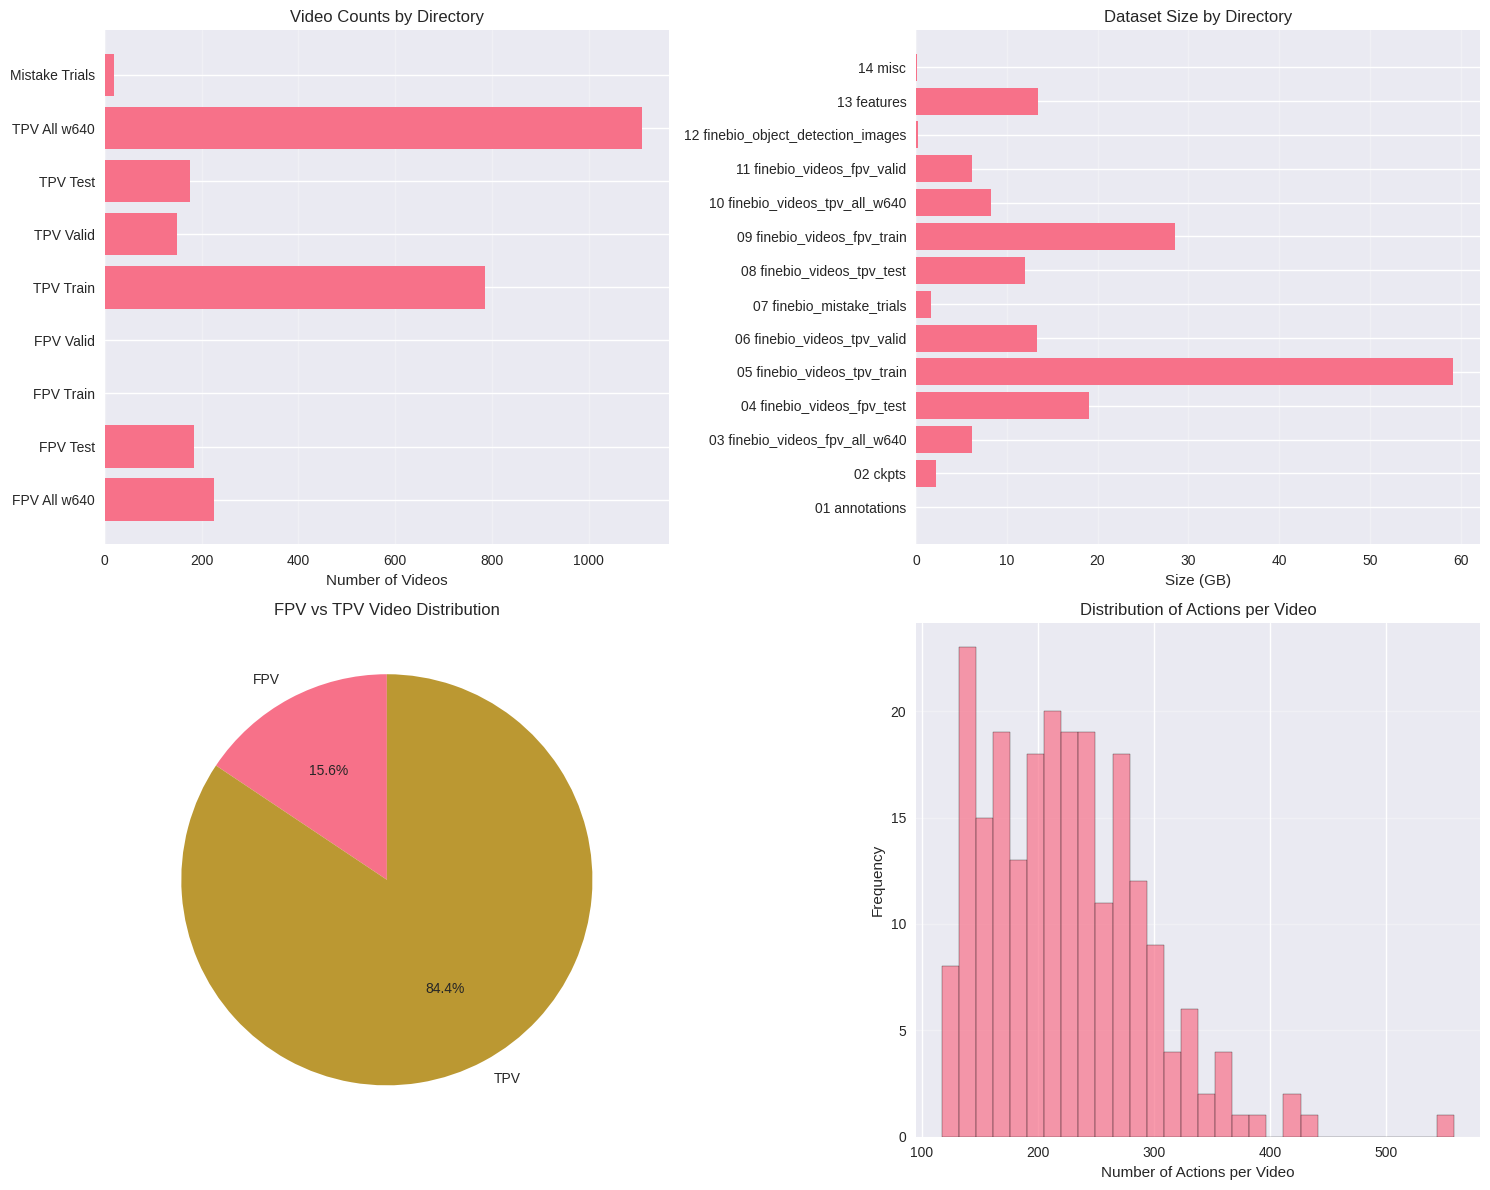


FINEBIO DATASET SUMMARY
Total dataset size: 0.24 GB
Total videos: 2631
  - FPV videos: 411
  - TPV videos: 2220
Total object detection images: 1935
Action annotation files: 226
COCO annotation files: 15
Unique participants: 32
Unique tasks: 7


In [14]:
# Create summary visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Video counts by directory
if video_stats:
    dir_names = list(video_stats.keys())
    counts = [video_stats[d]['count'] for d in dir_names]
    
    axes[0, 0].barh(dir_names, counts)
    axes[0, 0].set_xlabel('Number of Videos')
    axes[0, 0].set_title('Video Counts by Directory')
    axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Dataset size distribution
if directory_stats:
    dir_names = [d for d in directory_stats.keys() if d != "All Zip"]
    sizes_gb = [directory_stats[d]['total_size']/(1024**3) for d in dir_names]
    
    axes[0, 1].barh(dir_names, sizes_gb)
    axes[0, 1].set_xlabel('Size (GB)')
    axes[0, 1].set_title('Dataset Size by Directory')
    axes[0, 1].grid(axis='x', alpha=0.3)

# 3. FPV vs TPV video distribution
if 'df_videos' in locals():
    fpv_tpv_counts = df_videos['directory'].value_counts()
    fpv_count = sum(count for dir_name, count in fpv_tpv_counts.items() if 'FPV' in dir_name)
    tpv_count = sum(count for dir_name, count in fpv_tpv_counts.items() if 'TPV' in dir_name)
    
    axes[1, 0].pie([fpv_count, tpv_count], labels=['FPV', 'TPV'], autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('FPV vs TPV Video Distribution')

# 4. Action annotations distribution
if 'df_annotations' in locals():
    axes[1, 1].hist(df_annotations['num_actions'], bins=30, edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Number of Actions per Video')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Actions per Video')
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print final summary
print("\n" + "=" * 80)
print("FINEBIO DATASET SUMMARY")
print("=" * 80)
print(f"Total dataset size: {total_size/(1024**3):.2f} GB")
print(f"Total videos: {total_fpv + total_tpv}")
print(f"  - FPV videos: {total_fpv}")
print(f"  - TPV videos: {total_tpv}")
print(f"Total object detection images: {len(image_files) if 'image_files' in locals() else 'N/A'}")
print(f"Action annotation files: {len(action_files) if 'action_files' in locals() else 'N/A'}")
print(f"COCO annotation files: {len(coco_files) if 'coco_files' in locals() else 'N/A'}")
print(f"Unique participants: {df_videos['participant'].nunique() if 'df_videos' in locals() else 'N/A'}")
print(f"Unique tasks: {df_videos['task'].nunique() if 'df_videos' in locals() else 'N/A'}")
print("=" * 80)
